In [2]:
%load_ext cuml.accel
# %run /workspace/alvin/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/py_files/SSRtransforms_preloaded.py
import os
import re
import copy
import random
from collections import defaultdict
from joblib import Parallel, delayed
from tqdm import tqdm
import pickle
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from cuml.manifold import TSNE, UMAP

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, ConcatDataset, Subset, Dataset

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [3]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Uncomment only if you need 100% determinism and can handle errors
    # torch.use_deterministic_algorithms(True, warn_only=True)
    # os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    os.environ["PYTHONHASHSEED"] = str(seed)

def worker_init_fn(worker_id):
    """DataLoader worker init for reproducibility"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [4]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [5]:
meas_ds = datasets.DatasetFolder(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

In [6]:
train_ds = filter_by_elev(meas_ds, {14, 15, 16})
test_ds  = filter_by_elev(meas_ds, {17})

ds_dict = {"train" : train_ds, "test": test_ds}
dataset_sizes = {"train" : len(train_ds), "test": len(test_ds)}

In [6]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]
 
train_loss = []
# val_loss = []
train_acc = []
# val_acc = []
 
for i, seed in enumerate(seed_lst):
    
    start = time.perf_counter()
    
    print(f"Training Run {i}: seed {seed}")
    set_seed(seed)
 
    dataloaders = {
        "train": DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        # "val": DataLoader(valid_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed)),
        "test": DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4, worker_init_fn=worker_init_fn, generator=torch.Generator().manual_seed(seed))
    }
 
    model = models.resnet18(weights = None)
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(train_ds.class_to_idx))
    )
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr = 3e-4, weight_decay = 2e-4)
    
    scheduler = CosineAnnealingLR(optimizer, T_max = 200, eta_min = 3e-7)
 
    # move model to GPU
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
 
    history = {
        "train_loss": [],
        # "val_loss": [],
        "train_acc": [],
        # "val_acc": []
    }
 
    # Training loop
    num_epochs = 200
    for epoch in range(num_epochs):
        print(f"Epoch {epoch}")
        if epoch == 0:

            print(f"First layer mean: {model.conv1.weight.data.mean():.6f}")
        for phase in ["train"]:
            if phase == "train":
                model.train()
            else:
                model.eval()
 
            running_loss = 0.0
            running_corrects = 0
 
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
 
                optimizer.zero_grad()
 
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
 
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
 
                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()
 
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
 
            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)
 
            print(f"{phase} Loss: {epoch_loss:.7f} Acc: {epoch_acc:.7f}")
 
        scheduler.step()
        print(f"Epoch {epoch} LR: {scheduler.get_last_lr()[0]:.10f}")
 
    print("Training complete!")
 
    train_loss.append(history["train_loss"])
    # val_loss.append(history["val_loss"])
    train_acc.append(history["train_acc"])
    # val_acc.append(history["val_acc"])
 
    torch.save(model.state_dict(), os.path.join(workspace, f"weights/SSR/Experiment_1/training_real_14_15_16/rn18_seed{seed}_b16.pth"))
    end = time.perf_counter()
    elapsed = end - start
    print(f"Training time for Seed {seed}: {elapsed:.2f}s")
 
train_loss = np.array(train_loss)
# val_loss = np.array(val_loss)
train_acc = np.array(train_acc)
# val_acc = np.array(val_acc)

Training Run 0: seed 10
Epoch 0
First layer mean: 0.000224
train Loss: 1.3123910 Acc: 0.5521092
Epoch 0 LR: 0.0002999815
Epoch 1
train Loss: 0.2005992 Acc: 0.9491315
Epoch 1 LR: 0.0002999261
Epoch 2
train Loss: 0.0393136 Acc: 0.9975186
Epoch 2 LR: 0.0002998336
Epoch 3
train Loss: 0.0232864 Acc: 0.9975186
Epoch 3 LR: 0.0002997043
Epoch 4
train Loss: 0.0096542 Acc: 1.0000000
Epoch 4 LR: 0.0002995381
Epoch 5
train Loss: 0.0036442 Acc: 1.0000000
Epoch 5 LR: 0.0002993350
Epoch 6
train Loss: 0.0030910 Acc: 1.0000000
Epoch 6 LR: 0.0002990950
Epoch 7
train Loss: 0.0024154 Acc: 1.0000000
Epoch 7 LR: 0.0002988184
Epoch 8
train Loss: 0.0016166 Acc: 1.0000000
Epoch 8 LR: 0.0002985050
Epoch 9
train Loss: 0.0030530 Acc: 1.0000000
Epoch 9 LR: 0.0002981551
Epoch 10
train Loss: 0.0330547 Acc: 0.9925558
Epoch 10 LR: 0.0002977686
Epoch 11
train Loss: 0.1523458 Acc: 0.9528536
Epoch 11 LR: 0.0002973457
Epoch 12
train Loss: 0.0863067 Acc: 0.9764268
Epoch 12 LR: 0.0002968865
Epoch 13
train Loss: 0.0180252 Ac

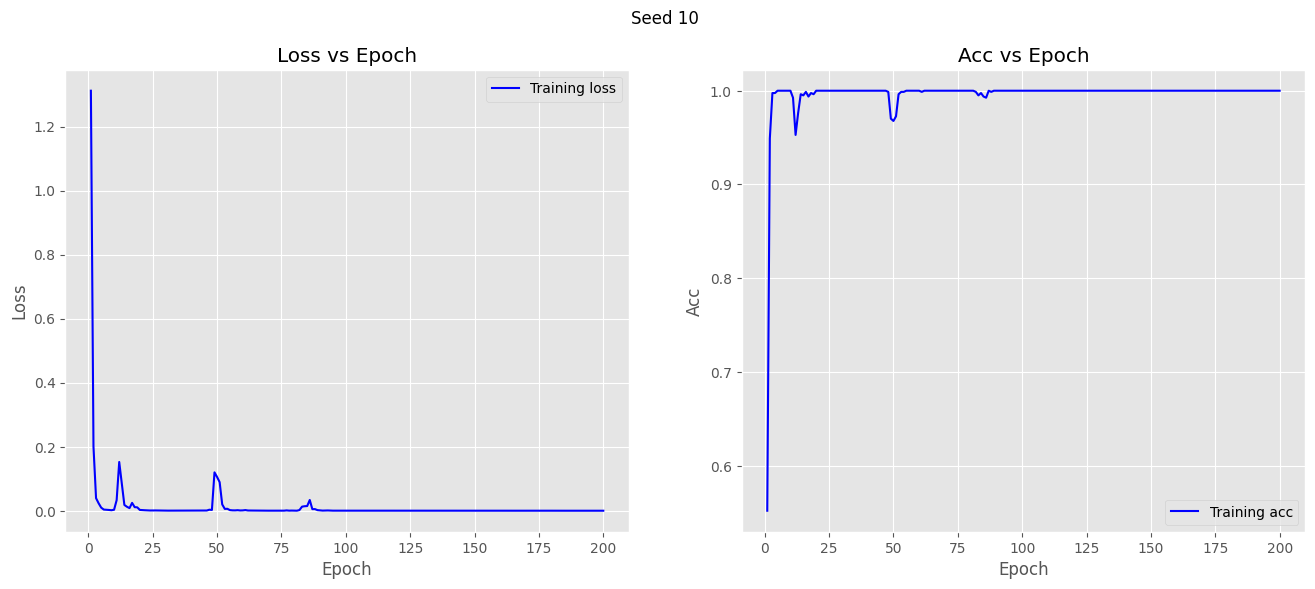

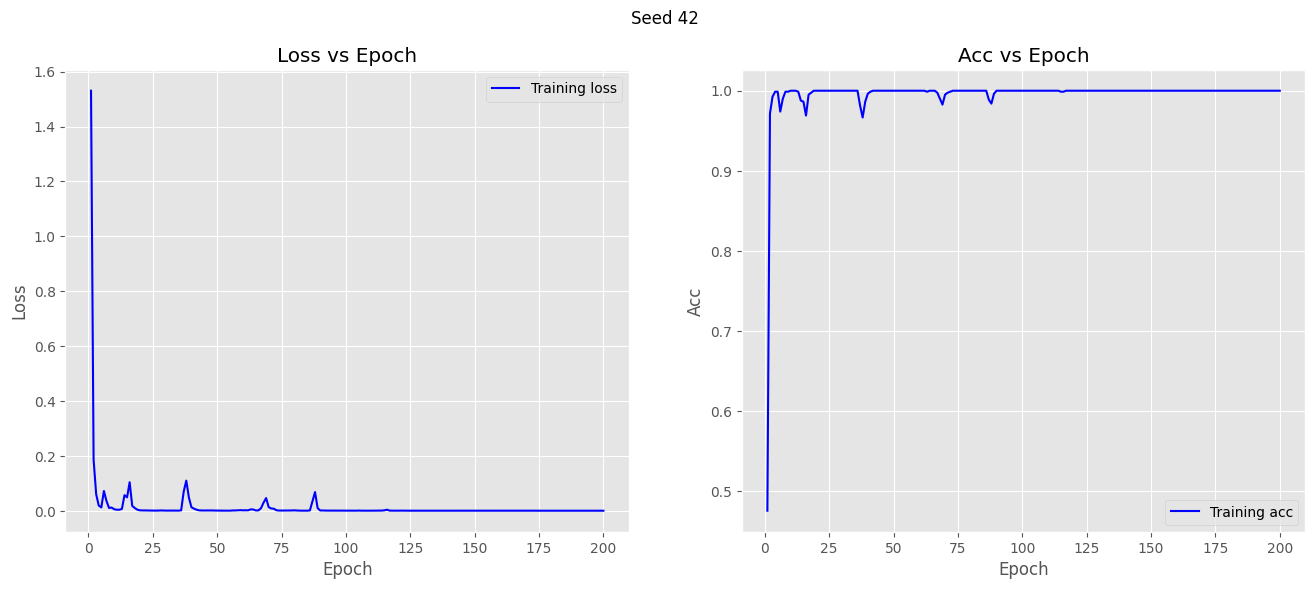

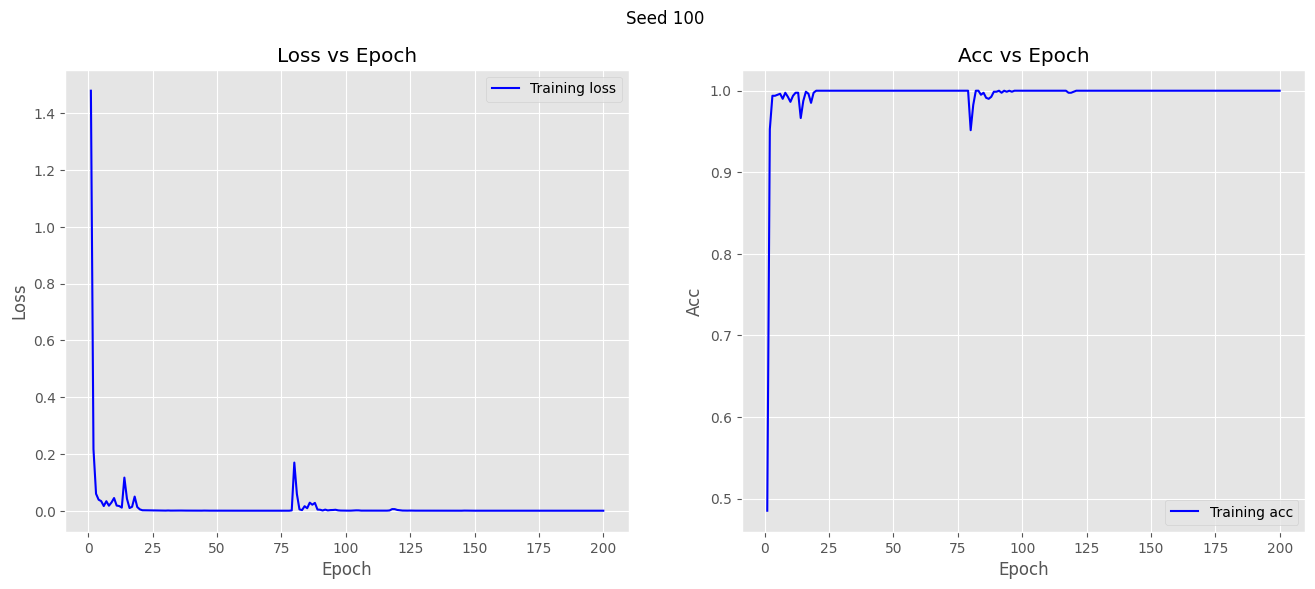

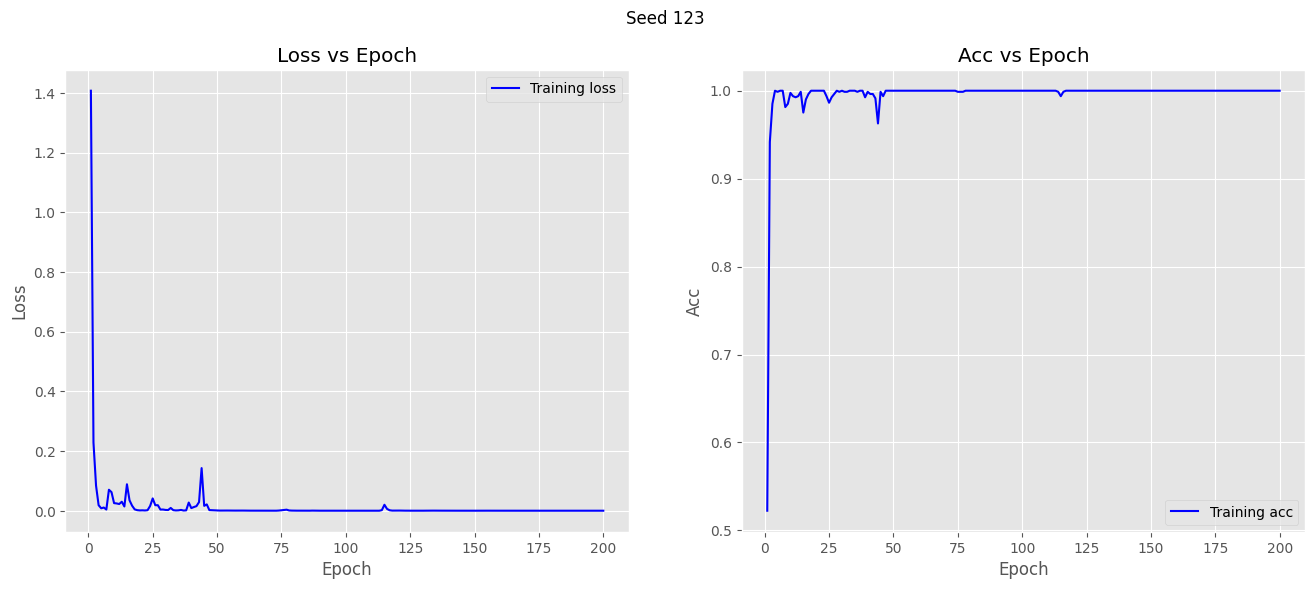

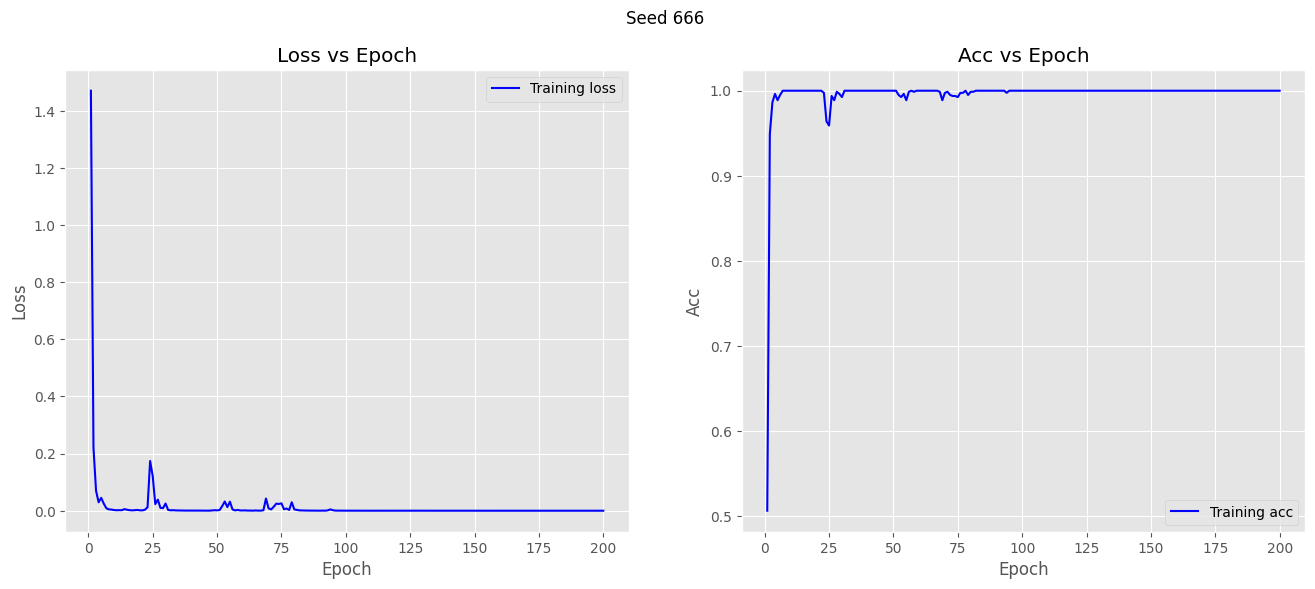

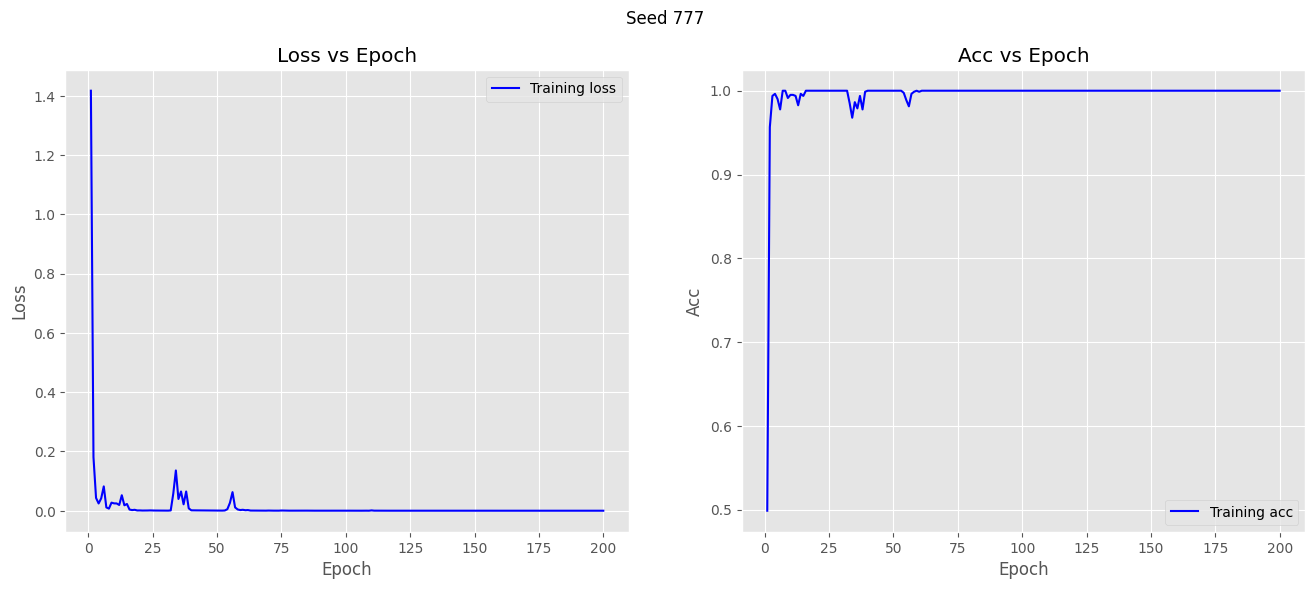

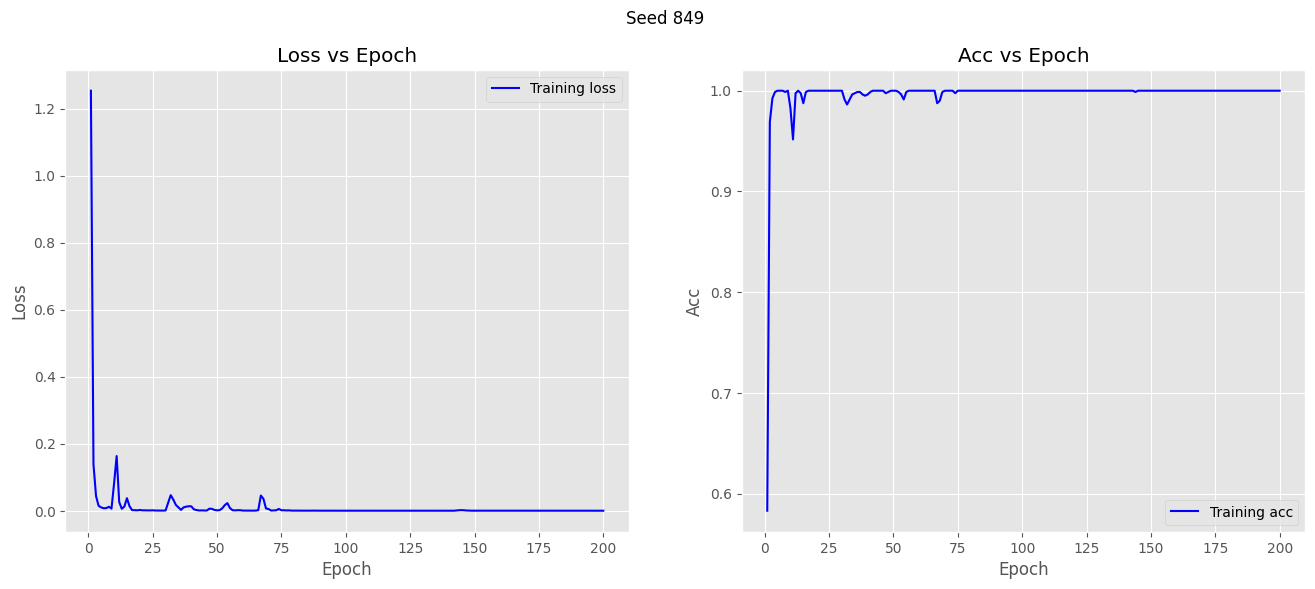

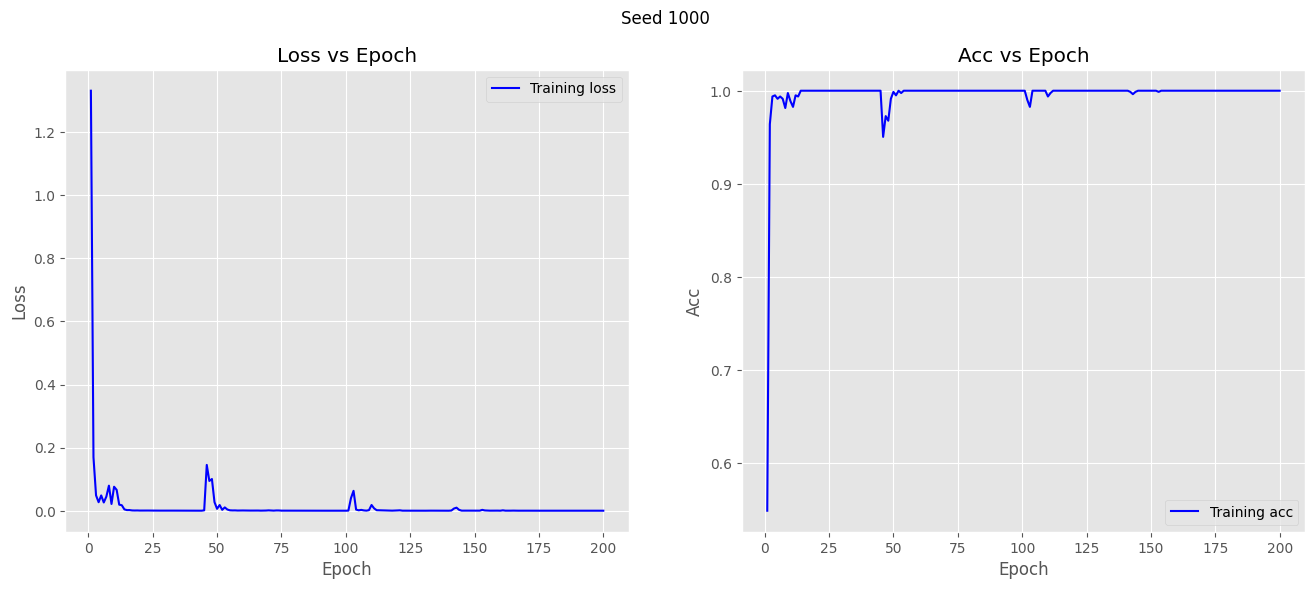

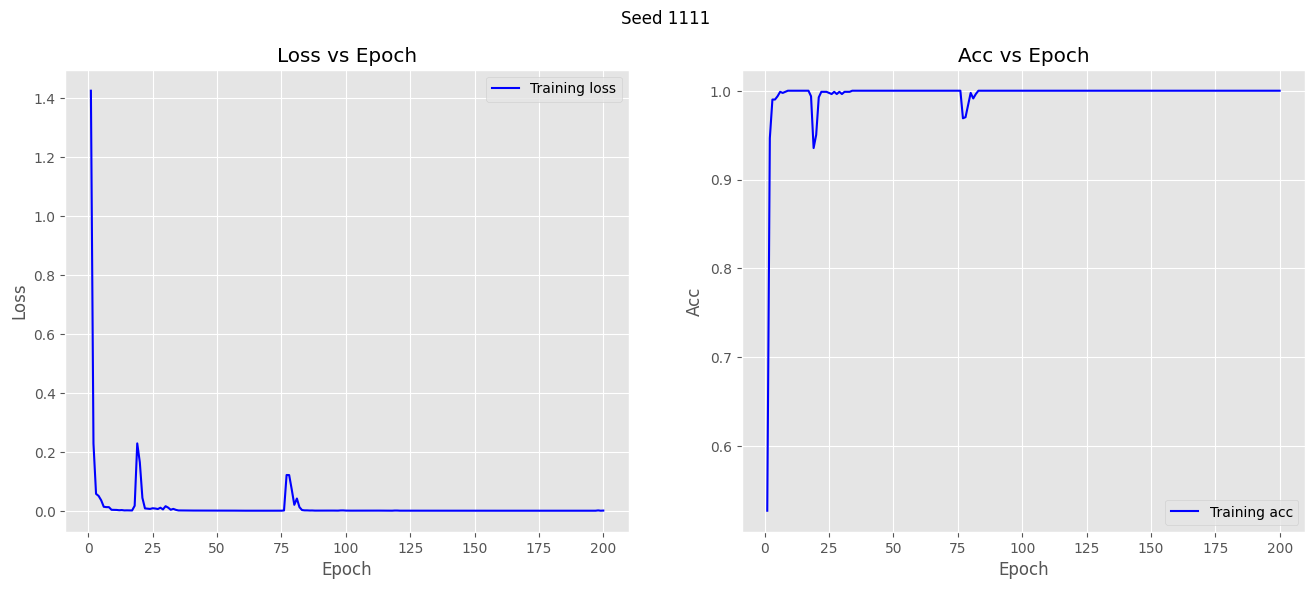

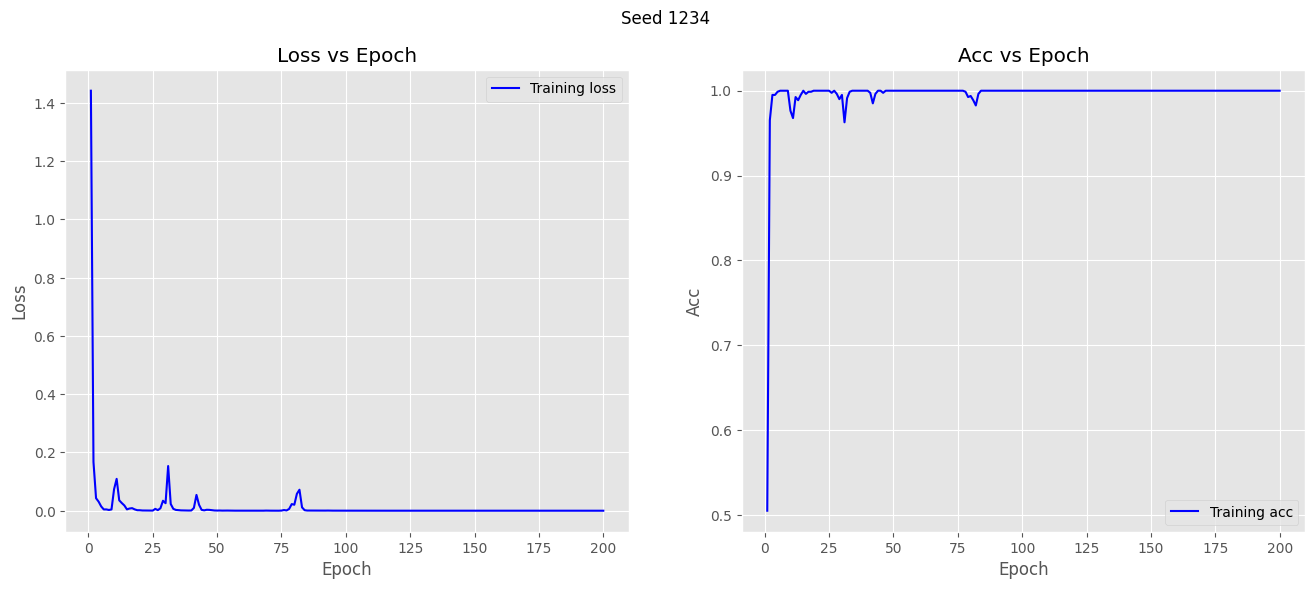

In [8]:
row, col = train_loss.shape

for i, seed in enumerate(seed_lst):
    
    with plt.style.context("ggplot"):
        fig = plt.figure(figsize = (16, 6))
    
        ax0 = fig.add_subplot(1, 2, 1)
        ax0.plot(np.arange(1, num_epochs+1), train_loss[i, :], label = "Training loss", c = "blue")
        # ax0.plot(np.arange(1, num_epochs+1), val_loss[i, :], label = "Validation loss", c = "green")
        ax0.set_title("Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("Loss")
        ax0.legend()
        ax0.grid(True)
        
        ax1 = fig.add_subplot(1, 2, 2)
        ax1.plot(np.arange(1, num_epochs+1), train_acc[i, :], label = "Training acc", c = "blue")
        # ax1.plot(np.arange(1, num_epochs+1), val_acc[i, :], label = "Validation acc", c = "green")
        ax1.set_title("Acc vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Acc")
        ax1.legend()
        ax1.grid(True)

        fig.suptitle(f"Seed {seed}")
        plt.show()

In [10]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []
for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    new_model = models.resnet18(weights = None)
    new_model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    )
    new_model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/training_real_14_15_16/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))
    
    
    new_model = new_model.to(device)
    new_model.eval()

    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            outputs = new_model(inputs)
            _, preds = torch.max(outputs, 1)
    
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)
    
    test_acc = correct / total
    print(f"Test Accuracy: {100*test_acc:.4f}")
    test_acc_lst.append(test_acc)

test_acc_arr = np.array(test_acc_lst)
print(f"Min: {test_acc_arr.min() * 100:.4f}")
print(f"Max: {test_acc_arr.max() * 100:.4f}")
print(f"Avg, Std: {test_acc_arr.mean() * 100:.4f}, {test_acc_arr.std() * 100:.4f}")

Evaluating Run 0: Seed 10
Test Accuracy: 100.0000
Evaluating Run 1: Seed 42
Test Accuracy: 100.0000
Evaluating Run 2: Seed 100
Test Accuracy: 100.0000
Evaluating Run 3: Seed 123
Test Accuracy: 100.0000
Evaluating Run 4: Seed 666
Test Accuracy: 100.0000
Evaluating Run 5: Seed 777
Test Accuracy: 100.0000
Evaluating Run 6: Seed 849
Test Accuracy: 100.0000
Evaluating Run 7: Seed 1000
Test Accuracy: 99.8145
Evaluating Run 8: Seed 1111
Test Accuracy: 100.0000
Evaluating Run 9: Seed 1234
Test Accuracy: 100.0000
Min: 99.8145
Max: 100.0000
Avg, Std: 99.9814, 0.0557


In [8]:
device = torch.cuda.set_device("cuda:0")
seed_lst = [10]
for i, seed in enumerate(seed_lst):
    set_seed(seed)
    model = models.resnet18(weights = None) # dont load ImageNet Weights
    # new_model.fc = nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
    model.fc = nn.Sequential(
        nn.Dropout(p = 0.4),
        nn.Linear(model.fc.in_features, len(meas_ds.class_to_idx))
    )
    # Load your trained weights
    model.load_state_dict(torch.load(
        os.path.join(workspace, f"weights/SSR/Experiment_1/training_real_14_15_16/rn18_seed{seed}_b16.pth"),
        map_location=device
    ))

    # this gives the synth_features and synth_labels
    train_meas_features, train_meas_labels, _ = _get_features_and_preds_from_model(model, train_ds, device, seed)
    test_meas_features, test_meas_labels, test_meas_preds = _get_features_and_preds_from_model(model, test_ds, device, seed)

cosine_d_true_class, cosine_n_true_class = k_nearest_neighbors_by_true_class(test_meas_features, test_meas_labels, train_meas_features, train_meas_labels, metric = "cosine")

print(f"Neighbors = 5")

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5
)

results, azim_diffs = azim_agreement_analysis_by_class(
    test_ds, test_meas_labels, test_meas_preds,
    train_ds, cosine_n_true_class,
    q_values=[1, 3, 5],
    k = 5, normalise = False

)

Neighbors = 5
Class       q= 1  q= 3  q= 5
----------------------------
2s1         0.500  0.621  0.724  (n=58)
bmp2        0.673  0.885  0.942  (n=52)
btr70       0.673  0.857  0.898  (n=49)
m1          0.647  0.804  0.843  (n=51)
m2          0.491  0.660  0.774  (n=53)
m35         0.491  0.642  0.698  (n=53)
m548        0.679  0.906  0.906  (n=53)
m60         0.550  0.750  0.817  (n=60)
t72         0.615  0.827  0.962  (n=52)
zsu23       0.603  0.862  0.914  (n=58)
----------------------------
Overall     0.590  0.779  0.846  (n=539)
Class       q= 1  q= 3  q= 5
----------------------------
2s1         29.000  36.000  42.000  (n=58)
bmp2        35.000  46.000  49.000  (n=52)
btr70       33.000  42.000  44.000  (n=49)
m1          33.000  41.000  43.000  (n=51)
m2          26.000  35.000  41.000  (n=53)
m35         26.000  34.000  37.000  (n=53)
m548        36.000  48.000  48.000  (n=53)
m60         33.000  45.000  49.000  (n=60)
t72         32.000  43.000  50.000  (n=52)
zsu23       3

In [11]:
shifted_left_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -5, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_right_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 15, axis = -1), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_up_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = 10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
shifted_down_meas_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/real"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), CircularShift(shift_pixels = -10, axis = -2), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

shifted_left_17 = filter_by_elev(shifted_left_meas_ds, {17})
shifted_right_17 = filter_by_elev(shifted_right_meas_ds, {17})
shifted_up_17 = filter_by_elev(shifted_up_meas_ds, {17})
shifted_down_17 = filter_by_elev(shifted_down_meas_ds, {17})

In [12]:
seed_lst = [10, 42, 100, 123, 666, 777, 849, 1000, 1111, 1234]

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
test_acc_lst = []

for i, seed in enumerate(seed_lst):
    print(f"Evaluating Run {i}: Seed {seed}")
    
    for ds in [test_ds, shifted_left_17, shifted_right_17, shifted_up_17, shifted_down_17]:
        
        if ds is shifted_left_17:
            print("shifted left by 5 units")
        elif ds is shifted_right_17:
            print("shifted right by 15 units")
        elif ds is shifted_up_17:
            print("shifted up by 10 units")
        elif ds is shifted_down_17:
            print("shifted down by 10 units")
        elif ds is test_ds:
            print("unshifted")
    
        new_model = models.resnet18(weights = None)
        new_model.fc = nn.Sequential(
            nn.Dropout(p = 0.4),
            nn.Linear(new_model.fc.in_features, len(train_ds.class_to_idx))
        )
        new_model.load_state_dict(torch.load(
            os.path.join(workspace, f"weights/SSR/Experiment_1/training_real_14_15_16/rn18_seed{seed}_b16.pth"),
            map_location=device
        ))
            
        new_model = new_model.to(device)
        new_model.eval()
        
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in DataLoader(ds, batch_size=32, shuffle=False, num_workers=8, pin_memory = True, persistent_workers=True):
                inputs = inputs.to(device)
                labels = labels.to(device)
        
                outputs = new_model(inputs)
                _, preds = torch.max(outputs, 1)
        
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)
        
        test_acc = correct / total
        print(f"Test Accuracy: {100*test_acc:.4f}")
        test_acc_lst.append(test_acc)
    print("\n")

Evaluating Run 0: Seed 10
unshifted
Test Accuracy: 100.0000
shifted left by 5 units
Test Accuracy: 75.1391
shifted right by 15 units
Test Accuracy: 12.0594
shifted up by 10 units
Test Accuracy: 19.2950
shifted down by 10 units
Test Accuracy: 21.1503


Evaluating Run 1: Seed 42
unshifted
Test Accuracy: 100.0000
shifted left by 5 units
Test Accuracy: 80.1484
shifted right by 15 units
Test Accuracy: 9.4620
shifted up by 10 units
Test Accuracy: 22.6345
shifted down by 10 units
Test Accuracy: 20.7792


Evaluating Run 2: Seed 100
unshifted
Test Accuracy: 100.0000
shifted left by 5 units
Test Accuracy: 75.8813
shifted right by 15 units
Test Accuracy: 15.3989
shifted up by 10 units
Test Accuracy: 18.5529
shifted down by 10 units
Test Accuracy: 22.2635


Evaluating Run 3: Seed 123
unshifted
Test Accuracy: 100.0000
shifted left by 5 units
Test Accuracy: 79.9629
shifted right by 15 units
Test Accuracy: 7.6067
shifted up by 10 units
Test Accuracy: 18.9239
shifted down by 10 units
Test Accuracy: 20